## Ridge and LAsso Regression implementation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
dataset=pd.read_csv("boston.csv")

In [5]:
dataset.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [6]:
dataset.shape

(506, 15)

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  B           506 non-null    float64
 13  LSTAT       506 non-null    float64
 14  Price       506 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 59.4 KB


In [7]:
X=dataset.iloc[:,1:-1] ## independent features
y=dataset.iloc[:,-1] ## dependent features

In [8]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [11]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: Price, Length: 506, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,shuffle=True, random_state=10)

In [13]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((354, 13), (152, 13), (354,), (152,))

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [15]:
mlr = LinearRegression()
mlr.fit(X_train,y_train)
y_pred_train = mlr.predict(X_train)
y_pred_test = mlr.predict(X_test)

In [16]:
r2_score(y_train,y_pred_train)

0.7495400632086622

In [17]:
r2_score(y_test,y_pred_test)

0.6996255772983107

In [18]:
from sklearn.linear_model import Lasso,Ridge

In [19]:
l = Lasso(alpha=0.01) #alpha is penalty parameter(Hyper parameter)
l.fit(X_train,y_train)
y_train_pred = l.predict(X_train)
y_test_pred = l.predict(X_test)

In [20]:
r2_score(y_train,y_train_pred)

0.749077810854496

In [21]:
r2_score(y_test,y_test_pred)

0.6966502079097381

In [22]:
r = Ridge(alpha=30)
r.fit(X_train,y_train)
y_train_pred = r.predict(X_train)
y_test_pred = r.predict(X_test)

In [23]:
r2_score(y_train,y_train_pred)

0.737781298571056

In [24]:
r2_score(y_test,y_test_pred)

0.6717978627567854

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
mm_scale = StandardScaler()
x_train_scale = mm_scale.fit_transform(X_train).round(3)
x_train_scale

In [ ]:
x_test_scale = mm_scale.fit_transform(X_test)
x_test_scale

In [ ]:
mlr = LinearRegression()
mlr.fit(x_train_scale,y_train)
train_pred = mlr.predict(x_train_scale)
test_pred = mlr.predict(x_test_scale)

In [ ]:
r2_score(y_train,train_pred)

In [ ]:
r2_score(y_test,test_pred)

In [ ]:
from matplotlib import pyplot  as plt

CRIM


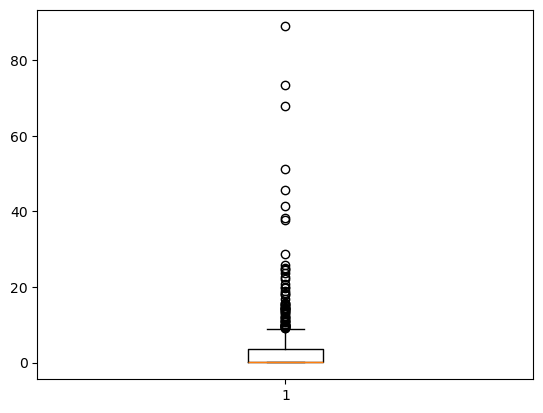

ZN


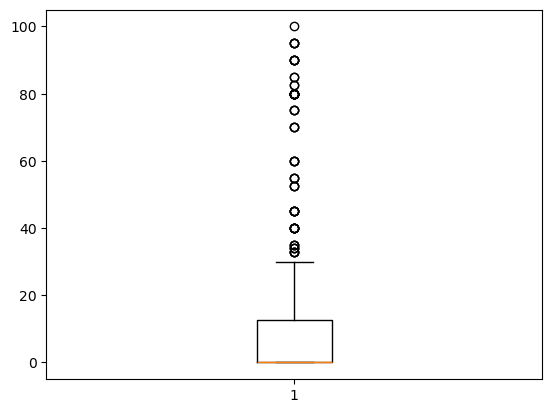

INDUS


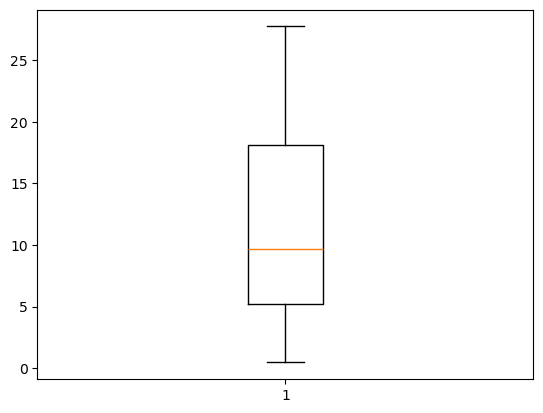

CHAS


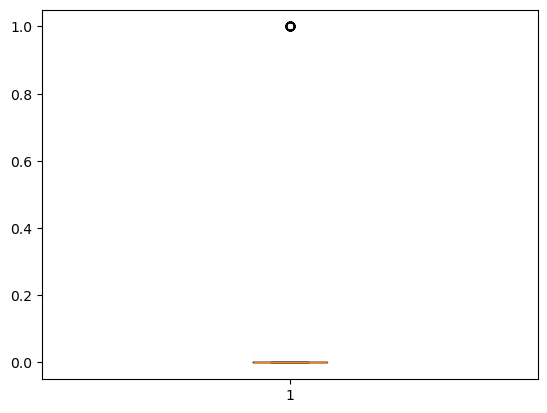

NOX


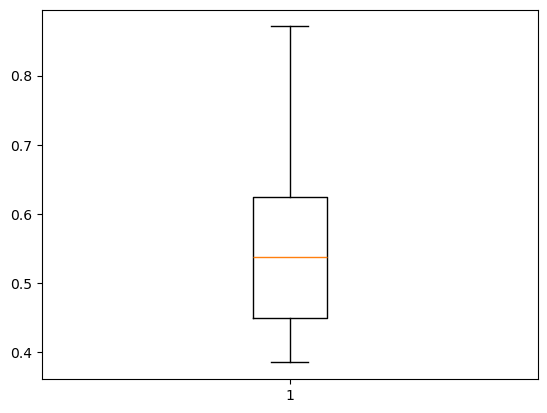

RM


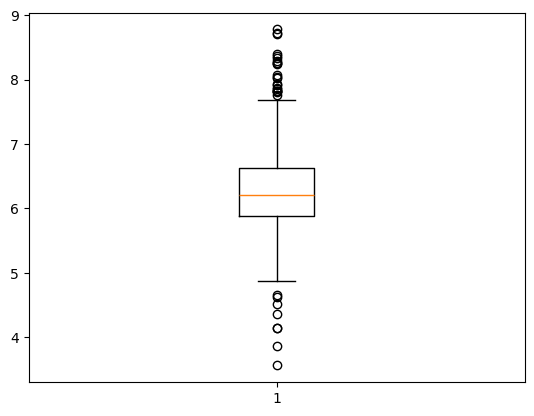

AGE


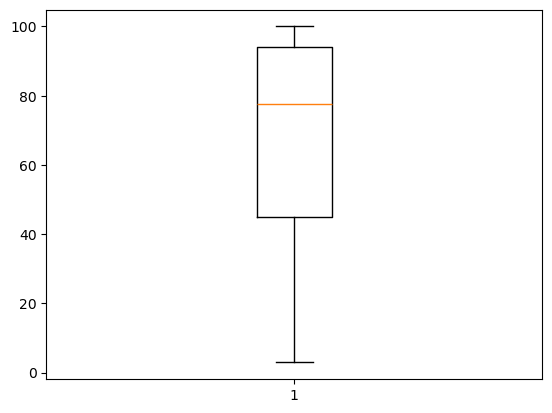

DIS


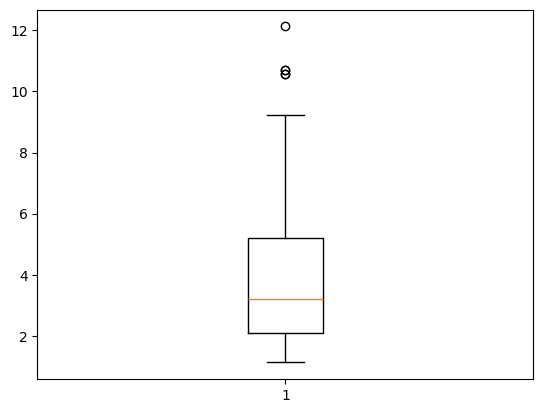

RAD


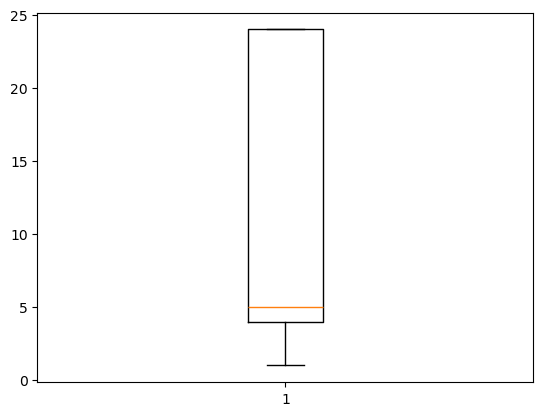

TAX


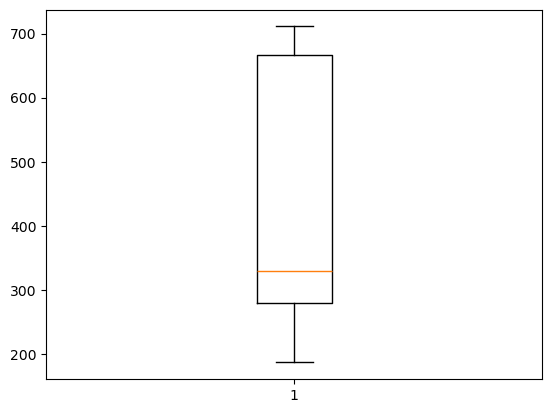

PTRATIO


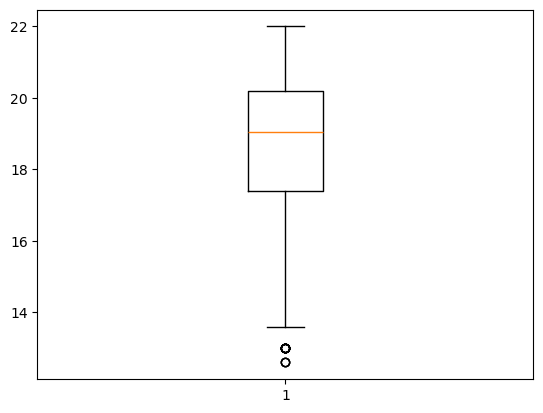

B


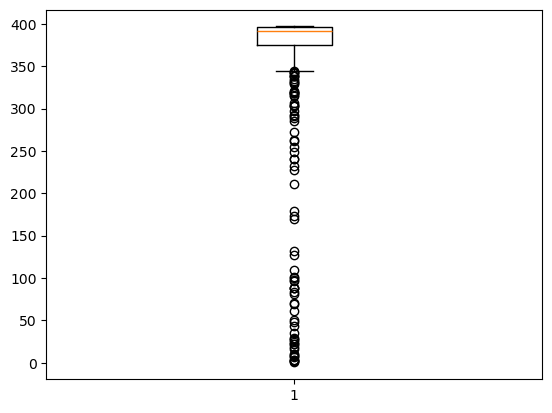

LSTAT


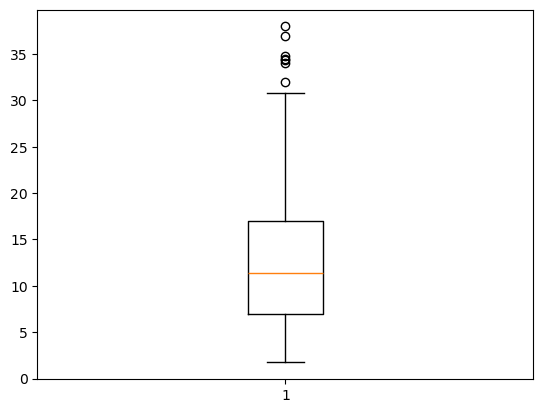

In [25]:
for i in X.columns:
    print(i)
    plt.boxplot(X[i])
    plt.show()

In [ ]:
X.columns

In [27]:
train = pd.read_csv("train.csv")
train

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984
...,...,...
695,58.0,58.595006
696,93.0,94.625094
697,82.0,88.603770
698,66.0,63.648685


In [39]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


In [40]:
train.duplicated().sum()

np.int64(0)

In [83]:
x = train[['x']]

In [84]:
y = train[['y']]

In [85]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,shuffle=True,random_state=10)

In [86]:
train.isnull().sum()

x    0
y    0
dtype: int64

In [87]:
train_cleaned = train.dropna(subset=['y'],inplace=True)

In [88]:
x = train_cleaned[['x']]

TypeError: 'NoneType' object is not subscriptable

In [80]:
y = train_cleaned[['y']]

TypeError: 'NoneType' object is not subscriptable

In [89]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred_train = lr.predict(x_train)
y_pred_test = lr.predict(x_test)

In [90]:
r2_score(y_train,y_pred_train)

0.9908255903363271

## Linear Regression


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lin_regressor=LinearRegression()
mse=cross_val_score(lin_regressor,X,y,scoring='neg_mean_squared_error',cv=5)
mean_mse=np.mean(mse)
print(mean_mse)

## Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge=Ridge()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
ridge_regressor=GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(X,y)

In [ ]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

## Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso=Lasso()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)

lasso_regressor.fit(X,y)
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
prediction_lasso=lasso_regressor.predict(X_test)
prediction_ridge=ridge_regressor.predict(X_test)

In [ ]:
import seaborn as sns

sns.distplot(y_test-prediction_lasso)

In [ ]:
import seaborn as sns

sns.distplot(y_test-prediction_ridge)